<a href="https://colab.research.google.com/github/alimoorreza/CS181-Fall26-Notebook-1/blob/main/assignment_1_convolving_gaussian_filter_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(164, 177, 3)
(164, 177)


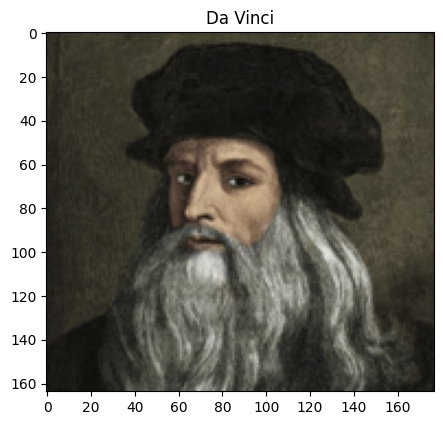

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import numpy as np
import pdb
import sys
from scipy.io import savemat

img_pil = Image.open('/content/drive/MyDrive/cs181_fall26/notebook_assignments/assignment1/input_images/da_vinci_lowres.png').convert('RGB')
img_pil_array = np.asarray(img_pil)

plt.figure(figsize=(5,5)) # figure size (5 inch, 5 inch)
plt.imshow(img_pil_array, cmap='gray')
plt.title('Da Vinci')
print(img_pil_array.shape)

rows = img_pil_array.shape[0]
cols = img_pil_array.shape[1]
#print(rows, cols)

# get the separate channels
img_pil_array_r = np.array(img_pil.getchannel(0))
img_pil_array_g = np.array(img_pil.getchannel(1))
img_pil_array_b = np.array(img_pil.getchannel(2))

print(img_pil_array_r.shape)

In [ ]:
def get_normal_dist1d(x, mean_mu, std_sigma):
  numer = np.exp(-(x - mean_mu)**2/(2*std_sigma**2))
  denom = (2*np.pi*(std_sigma**2))**0.5
  return numer/denom

In [ ]:
def make_kernel(k=5, mean_mu=0, std_sigma=1):

    kernel_size = 2*k+1 # kernel of size (2k+1, 2k+1)

    H           = np.ones((kernel_size, kernel_size))

    indices_x = [x for x in range(-k, k+1)]
    indices_y = [y for y in range(-k, k+1)]

    for y in indices_y:
        for x in indices_x:
            H[y+k, x+k] = get_normal_dist1d(x, mean_mu, std_sigma)*get_normal_dist1d(y, mean_mu, std_sigma)

    plt.figure(figsize=(3,3))
    plt.imshow(H)

    return H, kernel_size

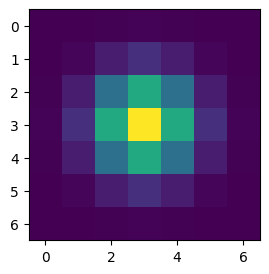

In [ ]:
# creating 'H' a Gaussian filter of size 7x7, mean=0, standard deviation=1
half_kernel_size_1      = 3
H_1, kernel_size_1      = make_kernel(k=half_kernel_size_1, mean_mu=0, std_sigma=1)


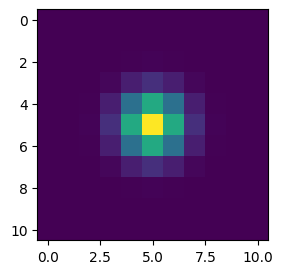

In [ ]:
# creating 'H' a Gaussian filter of size 11x11, mean=0, standard deviation=1
half_kernel_size_1      = 5
mean_mu_1               = 0
std_sigma_1             = 1
H_1, kernel_size_1      = make_kernel(k=half_kernel_size_1, mean_mu=mean_mu_1, std_sigma=std_sigma_1)


#**Subtask\#1: Modify the Gaussian filter parameters and observe how the changes affect the kernel values at different locations**
> Try Gaussian kernel parameters:

>> of size 21x21, mean=0, standard deviation=5

>> of size 21x21, mean=0, standard deviation=10


> Observe how the The nice thing about the smooth Gaussian filter is it emphasizes the highly on the center pixel.

> Smooth Gaussian filter emphasized the pixel data that is right at the center, it will also incorporate the data that are further out but they can not contribute as heavily as the center pixel. Because the value at the center of the Gaussian kernel has the highest magnitude.


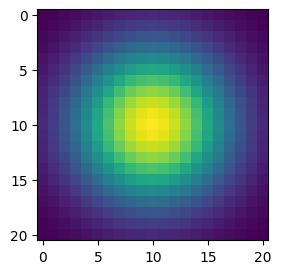

In [ ]:
# kernel H_2 parameters
# your code here for Gaussian filter of size 21x21, mean=0, standard deviation=5
# use variable name 'H_2' for filter

# ...
# ...
# ...

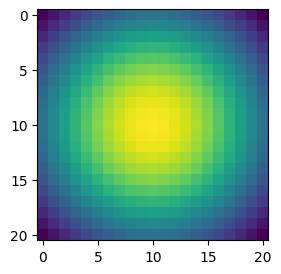

In [ ]:
# your code here for Gaussian filter of size 21x21, mean=0, standard deviation=10
# use variable name 'H_3' for filter

# ...
# ...
# ...


#**Convolution operation with a Gaussian filter**
The function below applies a convolution operation to a 2D grayscale input image of size `width x height`. It takes several parameters, including:

- an input_grayscale_image `img_pil_array`,
- a convolution kernel `H`,
- an integer value `k`, representing half the size of the kernel, and
- the full kernel size, `kernel_size`.

The function returns a convolved 2D grid, which can be thought of as another output grayscale image.

In [ ]:
def compute_convolution_grayscale(img_pil_array, H, k, kernel_size):

  # compute convolution
  F                 = img_pil_array
  new_img_pil_array = np.zeros((img_pil_array.shape[0], img_pil_array.shape[1]))

  i = 0
  for y in range(kernel_size, rows-kernel_size):
    for x in range(kernel_size, cols-kernel_size):

      # compute convolution centered at pixel location (x, y)
      # old_pixel_value = F.getpixel((x, y))

      old_pixel_value = F[y, x]
      new_pixel_value = 0.0

      for v_row in range(-k,k+1):
        for u_col in range(-k,k+1):
          #cur_pixel_value  = F.getpixel((x - u_col, y - v_row))
          cur_pixel_value  = F[y - v_row, x - u_col]
          cur_kernel_value = H[v_row + k, u_col + k] # small trick to adjust the indexing
          new_pixel_value  = new_pixel_value + float(cur_pixel_value)*cur_kernel_value

      # update the value at location (x,y) with newly computed pixel value
      new_img_pil_array[y, x] = round(new_pixel_value)
      #print('old_value=', old_pixel_value, ': new_value=', round(new_pixel_value))
      #new_img.putpixel((x, y), round(new_pixel_value))

      i = i + 1

  return new_img_pil_array

##**Apply the convolution operation to an RGB image***
You can apply the convolution operation separately to each channel of the input volume. Each channel will produce a separate convolved output. You can then superimpose the three outputs to display the final result of the convolution. For example, we apply our Gaussian kernel `H_1` to the Da Vinci image as follows:

Text(0.5, 1.0, 'Convolved image with Gaussian kernel (0,1)')

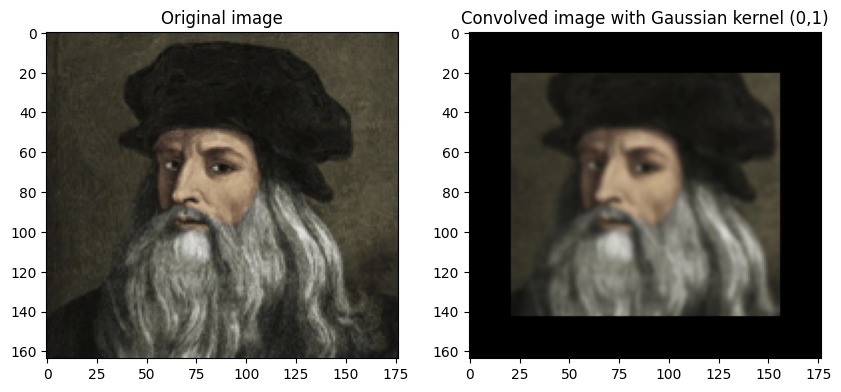

In [ ]:
new_img_pil_array_r      = compute_convolution_grayscale(img_pil_array_r, H_1, half_kernel_size_1, kernel_size_1)
new_img_pil_array_g      = compute_convolution_grayscale(img_pil_array_g, H_1, half_kernel_size_1, kernel_size_1)
new_img_pil_array_b      = compute_convolution_grayscale(img_pil_array_b, H_1, half_kernel_size_1, kernel_size_1)
new_img_pil_array        = np.zeros((img_pil_array_r.shape[0], img_pil_array_r.shape[1], 3))
new_img_pil_array[:,:,0] = new_img_pil_array_r
new_img_pil_array[:,:,1] = new_img_pil_array_g
new_img_pil_array[:,:,2] = new_img_pil_array_b
new_img = Image.fromarray(new_img_pil_array.astype('uint8'))
#new_img = Image.fromarray(new_img_pil_array.astype('uint8'), mode='RGB')

#savemat('convolved.mat', {'red_channel':new_img_pil_array_r})
#new_img = Image.fromarray(new_img_pil_array_r, mode='L')
fig, axes = plt.subplots(1,2, figsize=(10, 10))
ax = axes[0]
ax.imshow(img_pil_array, cmap='gray')
ax.set_title('Original image')
ax = axes[1]
ax.imshow(new_img)
ax.set_title('Convolved image with Gaussian kernel (' + str(mean_mu_1) + ',' + str(std_sigma_1) + ')')
#new_img.save('davinci_convolved_gaussian_kernel_' + str(kernel_size) + '_sigma_' + str(std_sigma) + '.png')
#img_pil = ImageOps.grayscale(img_pil)

###**Subtask#2: Apply the `H_2` Gaussian filter you created in Task#1 to the Da Vinci image using a convolution operation, and observe the effects.**

In [ ]:
# your code
# ...
# ...
# ...


###**Subtask#3: Apply the `H_3` Gaussian filter you created in Task#1 to the Da Vinci image using a convolution operation, and observe the effects.**

In [ ]:
# your code
# ...
# ...
# ...
